https://github.com/4GeeksAcademy/boosting-algorithms-project-tutorial/blob/main/solution.ipynb

In [103]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
import lightgbm as lgb
import shap
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import RobustScaler

# **0. CONTEXTO Y CARGA DATOS**

Fuente: https://github.com/4GeeksAcademy/random-forest-project-tutorial/blob/main/README.es.md

Descripción de variables: 

- Pregnancies. Número de embarazos del paciente (numérico)

- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)

- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)

- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)

- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)

- BMI. Índice de masa corporal (numérico)

- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)

- Age. Edad del paciente (numérico)

- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

In [5]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores

### 1.1.1. Unicos

In [8]:
#Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [9]:
#Indice
dup_fil=df.duplicated().sum()
print("No hay filas duplicadas" if dup_fil==0 else "Hay filas duplicadas")

No hay filas duplicadas


In [10]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

In [12]:
# Columnas columnas con más de un 15% de valores faltantes
missing=df.isna().mean()*100
missing[missing>15]

Series([], dtype: float64)

<Axes: >

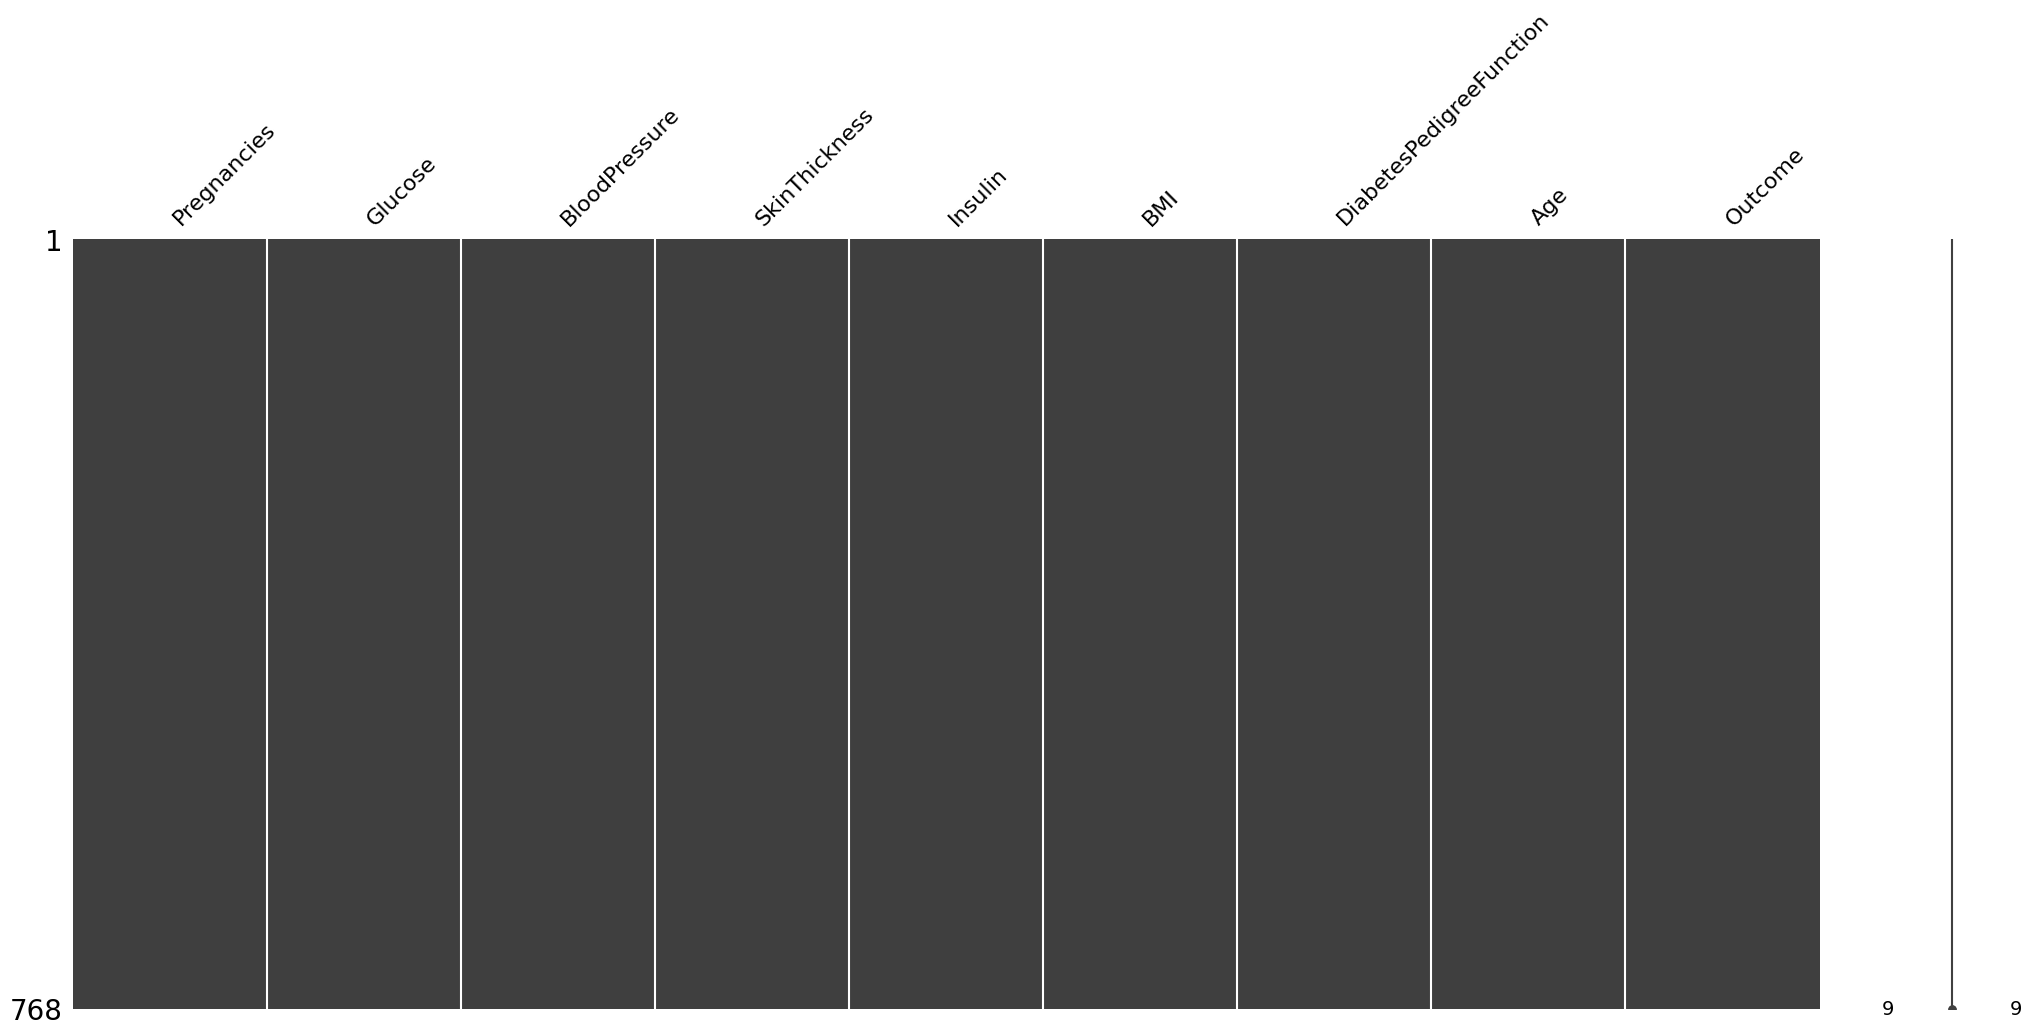

In [13]:
# Gráficamente
msno.matrix(df)

## 1.4. Codificar variables categoricas

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 1.5. División Train-Test

In [17]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0,0,0.0,0.304,21
618,9,112,82,24,0,28.2,1.282,50
346,1,139,46,19,83,28.7,0.654,22
294,0,161,50,0,0,21.9,0.254,65
231,6,134,80,37,370,46.2,0.238,46


## 1.6. Análisis de valores Outliers

In [18]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,3.742671,3.313264,0.000,1.0000,3.0000,6.00000,17.00
Glucose,614.0,120.855049,32.035057,0.000,100.0000,117.0000,139.00000,199.00
BloodPressure,614.0,69.415309,18.512599,0.000,64.0000,72.0000,80.00000,122.00
SkinThickness,614.0,20.399023,15.433974,0.000,0.0000,23.0000,32.00000,63.00
Insulin,614.0,81.438111,116.234835,0.000,0.0000,42.5000,129.75000,846.00
BMI,614.0,31.983388,7.740625,0.000,27.1000,32.0000,36.37500,67.10
DiabetesPedigreeFunction,614.0,0.469168,0.336847,0.078,0.2415,0.3725,0.61375,2.42
Age,614.0,32.907166,11.503437,21.000,24.0000,29.0000,40.00000,81.00


In [27]:
#Primer análisis de outliers (diferncia media-mediana)
valores=[]
variables=[X_train.columns]
for var in X_train.columns:
    valores.append(np.abs(X_train[var].mean()-X_train[var].median())/X_train[var].median()*100)

outliers=pd.Series(valores, index=variables)
outliers[outliers>15]

Pregnancies                 24.755700
Insulin                     91.619084
DiabetesPedigreeFunction    25.951074
dtype: float64

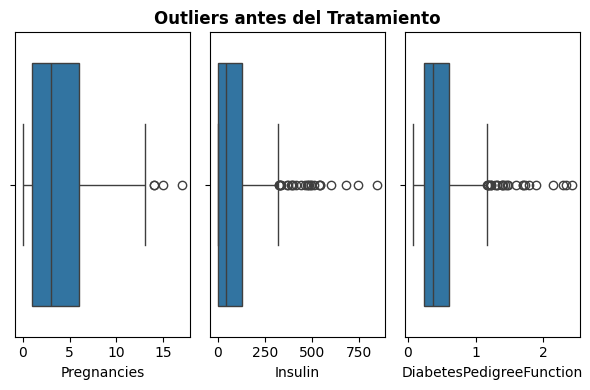

In [39]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, axis = plt.subplots(1, 3, figsize=(6, 4))

# Crear un histograma en el primer subplot
# Primera fila
sns.boxplot(data=X_train, x="Pregnancies", ax=axis[0])
sns.boxplot(data=X_train, x="Insulin", ax=axis[1])
sns.boxplot(data=X_train, x="DiabetesPedigreeFunction", ax=axis[2])
axis[1].set_title("Outliers antes del Tratamiento", fontweight="bold")


# Mostrar la figura
plt.tight_layout()
plt.show()

En este caso, se aprecia como insulin y DiabetesPedigreeFunction tienen un número elevado de outliers. Antes de tratarlas, vamos a analizar sus histogramas.

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


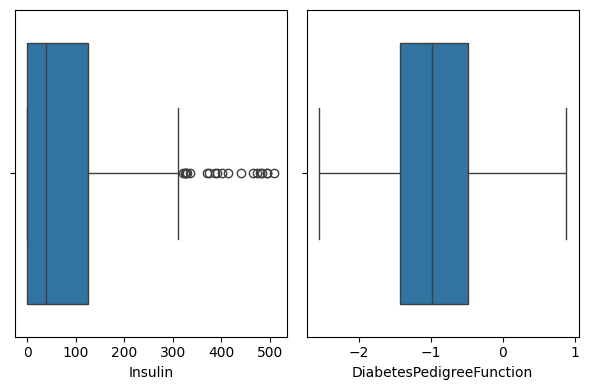

In [41]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, axis = plt.subplots(1, 2, figsize=(6, 4))

# Crear un histograma en el primer subplot
# Primera fila
sns.boxplot(data=X_train[X_train["Insulin"]<X_train["Insulin"].quantile(0.99)], x="Insulin", ax=axis[0])
sns.boxplot(data=np.log(X_train), x="DiabetesPedigreeFunction", ax=axis[1])

# Mostrar la figura
plt.tight_layout()
plt.show()

<Axes: ylabel='Insulin'>

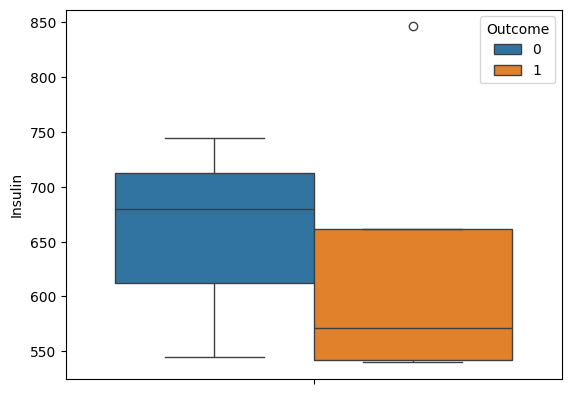

In [62]:
# Análisis de la distribución de los valores eliminados
data=pd.concat([y_train, X_train], axis=1)

sns.boxplot(data=data[data["Insulin"]>data["Insulin"].quantile(0.99)], y="Insulin", hue="Outcome")

In [63]:
# Realizamos los cambios en train
data=data[data["Insulin"]<data["Insulin"].quantile(0.99)] #Eliminamos valores extremos de insulin
data["DiabetesPedigreeFunction"]=np.log(data["DiabetesPedigreeFunction"])

#Realizamos el split
X_train_filt=data.drop(columns="Outcome")
y_train_filt=data["Outcome"]

In [64]:
# Realizamos los cambios en test
X_test["DiabetesPedigreeFunction"]=np.log(X_test["DiabetesPedigreeFunction"])

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


# **2. SELECCIÓN DE CARCATERÍSTICAS**

## 2.1. Aplicación de los métodos

### A) Feature importance con Random Forest

In [66]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train_filt, y_train_filt)

In [67]:
# Importancia de características
importances = model.feature_importances_*100

# Convertir a DataFrame
df_rf = pd.DataFrame({'feature': X_train_filt.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)

# Calculamos la importancia acumulada
df_rf['rf_importance_acum'] = df_rf['rf_importance'].cumsum()
df_rf

,feature,rf_importance,rf_importance_acum
1,Glucose,26.120223,26.120223
5,BMI,17.078045,43.198268
7,Age,14.165211,57.363478
6,DiabetesPedigreeFunction,12.280045,69.643524
2,BloodPressure,8.978381,78.621905
0,Pregnancies,7.770934,86.392839
3,SkinThickness,6.830900,93.223739
4,Insulin,6.776261,100.000000


### B) Permutation/Shuffle importance con Gradient Boosting Classifier

En nuestro caso, permutation importance proporciona el cambio en la métrica de scoring seleccionada cuando alteramos los valores de las características de estudio. Como en nuestro caso estamos trabajando con información médica, vamos a centrarnos en la métrica de f1 score pues comprende la precision y recall del modelo (de forma que máximizamos VP y min FN).

In [104]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train_filt, y_train_filt, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_gbc = GradientBoostingClassifier().fit(X_train1, y_train1)

In [143]:
# Realizamos 10 permutaciones por cada característica
perm = permutation_importance(model_gbc, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='f1')
df_perm = pd.DataFrame({'feature': X_train_filt.columns, 'perm': perm.importances_mean*100}).sort_values('perm', ascending=False)
df_perm

,feature,perm
1,Glucose,7.947218
4,Insulin,1.372230
5,BMI,0.013466
3,SkinThickness,-0.193566
6,DiabetesPedigreeFunction,-1.772432
7,Age,-2.681300
0,Pregnancies,-3.215594
2,BloodPressure,-4.375210


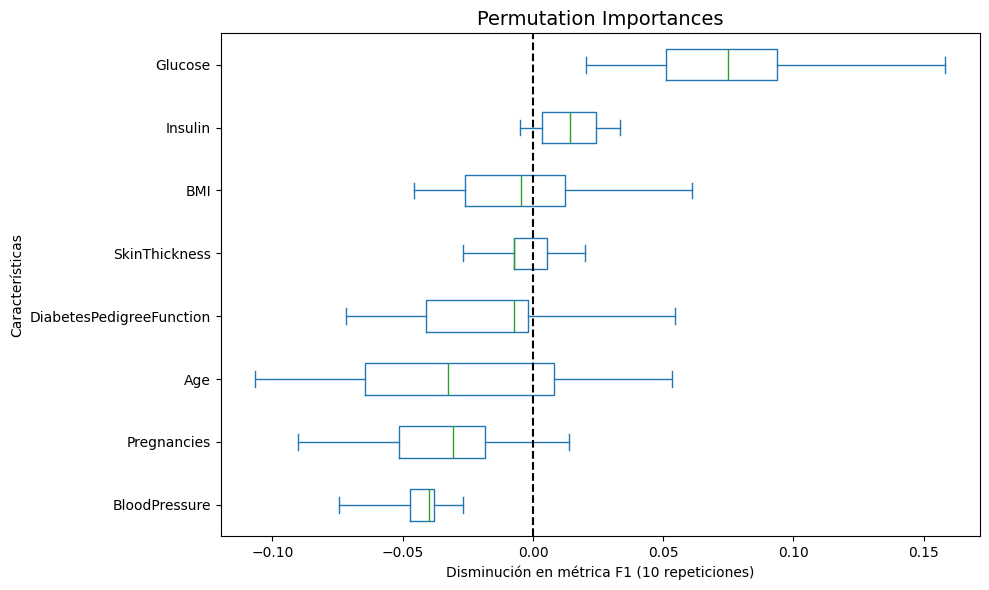

In [116]:
# Obtenemos orden de las variables (de menor a mayor importancia media)
# Esto asegura que el gráfico final estará ordenado
sorted_idx = perm.importances_mean.argsort()

# DataFrame para el Box Plot
# - Perm.importances: todos cambios en f1 por el numero de  repeticiones 
importances_df = pd.DataFrame(
    perm.importances[sorted_idx].T,
    columns=X_train_filt.columns[sorted_idx] 
)
importances_df

#Representamos gráficamente los cambios en el f1 score
fig, ax = plt.subplots(figsize=(10, 6))

# Usamos .plot.box() directamente sobre el DataFrame (columna por columna)
# vert=False -> gráfico horizontal
ax = importances_df.plot.box(vert=False, whis=10, ax=ax)
ax.set_title("Permutation Importances", fontsize=14)
ax.set_ylabel("Características")
ax.axvline(x=0, color="k", linestyle="--") # Línea vertical en 0 (sin ganancia/pérdida)
ax.set_xlabel("Disminución en métrica F1 (10 repeticiones)") 
fig.tight_layout()
plt.show()

### C) SHAP

In [132]:
# Calculamos shap con el modelo entrenado anteriormente
explainer = shap.Explainer(model_gbc, X_train1) # Creamos el objeto explainer usando el modelo y los datos de entrenamiento
shap_values = explainer.shap_values(X_val) # Calculamos los valores SHAP para los datos de validación (X_val)

In [135]:
# Media de la importancia de shap por cada característica
imp_shap = np.abs(shap_values).mean(axis=0) 
# Pasamos los valores a escala porcentual
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap = pd.DataFrame({"feature": X_val.columns, "shap": imp_shap_pct}).sort_values('shap', ascending=False)
df_shap

,feature,shap
1,Glucose,27.762812
5,BMI,20.455142
7,Age,17.299670
6,DiabetesPedigreeFunction,13.503784
2,BloodPressure,6.896852
0,Pregnancies,6.546430
3,SkinThickness,4.087806
4,Insulin,3.447504


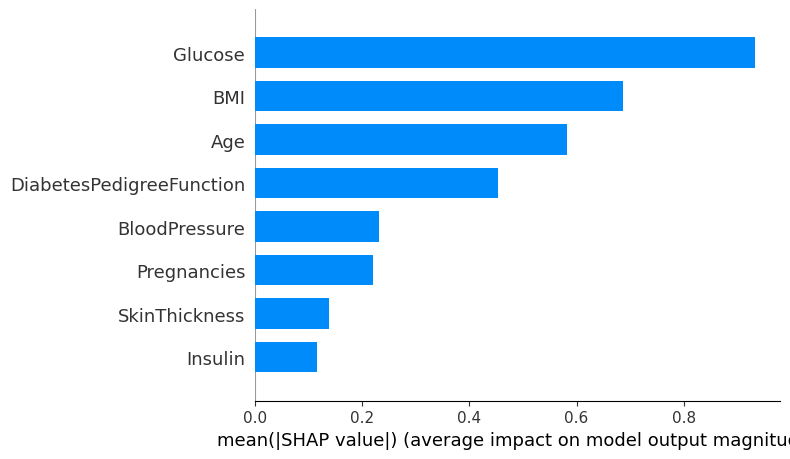

In [139]:
# Resumen gráfico de barras
shap.summary_plot(shap_values, X_val, plot_type="bar")

## 2.2. Selección de característica según los 3 métodos

In [144]:
df_importances = (
    df_rf.drop(columns="rf_importance_acum")
    .merge(df_perm, on='feature', how='outer')
    .merge(df_shap, on='feature', how='outer')
).sort_values('perm', ascending=False)

df_importances

,feature,rf_importance,perm,shap
4,Glucose,26.120223,7.947218,27.762812
5,Insulin,6.776261,1.372230,3.447504
1,BMI,17.078045,0.013466,20.455142
7,SkinThickness,6.830900,-0.193566,4.087806
3,DiabetesPedigreeFunction,12.280045,-1.772432,13.503784
0,Age,14.165211,-2.681300,17.299670
6,Pregnancies,7.770934,-3.215594,6.546430
2,BloodPressure,8.978381,-4.375210,6.896852


In [274]:
#Filtrado
df_filt = df_importances[(df_importances['rf_importance']>=1)&(df_importances['perm']>=1)&(df_importances['shap']>=1)]
df_filt

,feature,rf_importance,perm,shap,importancia_promedio
5,longitude,25.027879,40.694110,13.486182,26.402724
3,latitude,21.736263,16.033156,7.768779,15.179399
1,days_since_review,13.214814,31.782088,10.954370,18.650424
0,days_available,10.119010,11.981469,12.984192,11.694890
6,minimum_nights,8.674605,16.453186,8.052878,11.060223
10,room_type,6.154381,37.614902,27.909315,23.892866
4,lodging,5.883608,15.791780,4.117388,8.597592
9,reviews_per_month,3.875955,38.053599,4.994796,15.641450
8,number_of_reviews,3.471188,10.191409,4.947764,6.203454
7,neighbourhood_group,1.124472,11.562212,4.171699,5.619461


## 2.3. Comprobación vif y correlaciones

El VIF (variance inflation factor) cuantifica la intensidad de la multicolinealidad en un análisis de regresión normal de mínimos cuadrados.

- **Fórmula**: $\displaystyle \mathrm {FIV_{i}} ={\frac {1}{1-R_{i}^{2}}}$
    - donde R2i es el coeficiente de determinación de la ecuación de regresión del primer paso, con $\displaystyle X_{i}$ en el lado izquierdo y el resto de variables predictivas en el derecho.

In [275]:
# VIF
## Variable Xi: añdimos cte. para no sumir que regresión pasa por  (0,0)
x_vif=add_constant(X_train[df_filt["feature"].tolist()].drop(columns="days_since_review"))#Seleccionamos features de X_train menos days (NaN)

## Cálculo: x_vif.values (array con los datos), i valor de la columna que asuma Yi
vif = pd.Series([variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])], index=x_vif.columns).drop(index="const")
vif

longitude              1.903804
latitude               1.086301
days_available         1.142358
minimum_nights         1.057050
room_type              1.050665
lodging                1.103813
reviews_per_month      1.568498
number_of_reviews      1.549422
neighbourhood_group    1.904410
dtype: float64

Análisis:

- VIF <= 1: Ausencia de multicolinealidad. El predictor no está correlacionado con otros predictores, por lo que no infla el error típico ni afecta a la estabilidad del modelo.

- VIF entre 1 y 5: Multicolinealidad moderada. Existe cierta correlación con otros predictores, pero no suele ser grave.

- VIF > 5: Riesgo multicolinealidad. El error típico del predictor puede estar notablemente inflado, lo que puede hacer que su coeficiente sea menos fiable. Considera la posibilidad de tomar medidas para reducir la multicolinealidad, como eliminar o combinar los predictores correlacionados.

- VIF > 10: Multicolinealidad grave. El error típico del predictor está muy inflado y la estimación de su coeficiente es probablemente inestable. Suelen ser necesarias acciones correctoras, como eliminar el predictor o utilizar técnicas de regularización.

In [276]:
vif[vif>5]

Series([], dtype: float64)

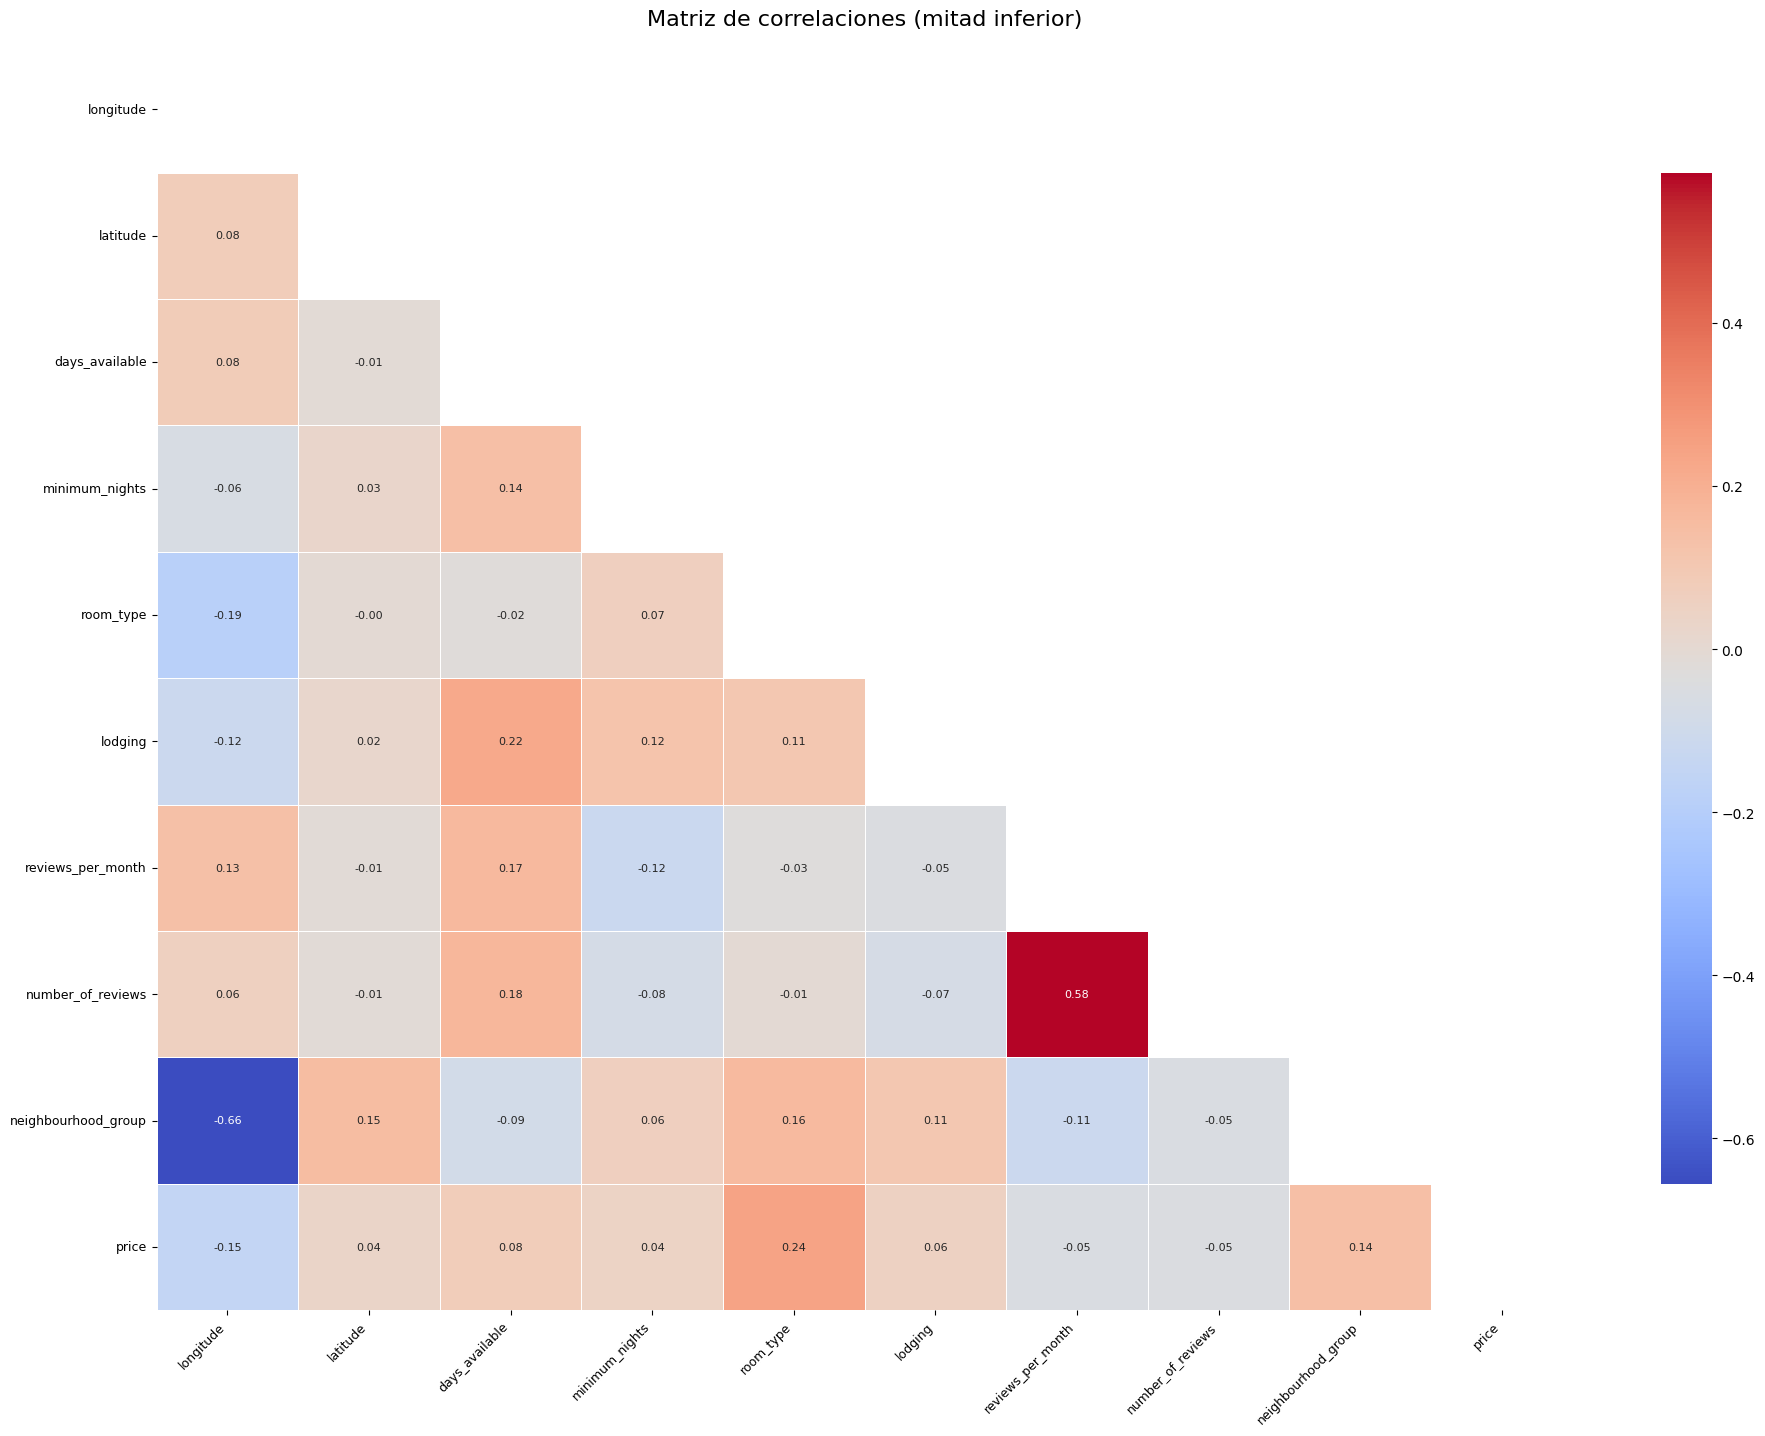

In [277]:
#Análisis de correlaciones entre regresores
x_vif.drop(columns="const", axis=1, inplace=True)
x_vif['price'] = y_train
corr = x_vif.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

#Mapa de correlaciones
plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

Tras analizar el VIF, es importante verificar el análisis con la **matriz de correlaciones**. De esta forma si se observa un valor por encima de +-0.6, hay que realizar validacción cruzada para ver si esas variables se solapan o no

En nuestro caso los valores de la correlación muestran una imporante relación en el ``neighbour_hood`` y la ``longitude``.


## 2.4. Cross_validation

En primer lugar, el hecho de tener una distribución asimétrica a la izquierda y con un número elevado de outliers nos motiva a logaritmizar la variable para suavizar dicha distribución y  reducir el error de las predicciones.

RIC

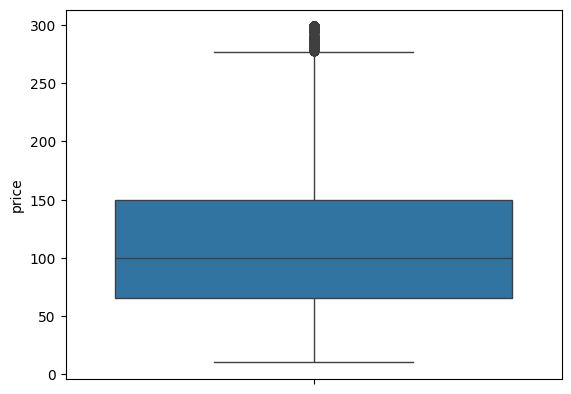

In [278]:
# Vamos a aplicar Winsorización (<p92.5)
cond=(df["price"]>df["price"].quantile(0.0001))&(df["price"]<df["price"].quantile(0.925))
sns.boxplot(df["price"][cond])

#Eliminamos las observaciones en los datos
outliers=y_train[cond].index
y_train.drop(index=outliers, axis=0, inplace=True)
x_vif.drop(index=outliers, axis=0, inplace=True)

In [279]:
# Versión 1: todas las características
cv_results1 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), x_vif, y_train, cv=10, scoring="r2")
# scoring metrics: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

In [288]:
print(f"R2 con todas las variables: {cv_results1.mean().round(5)*100} %")

R2 con todas las variables: 99.825 %


In [289]:
# Versión 2: todas las características
cv_results2 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), x_vif.drop(columns='neighbourhood_group',axis=1), y_train, cv=10, scoring='r2')

In [290]:
print(f"R2 con todas las longitude y latitude: {cv_results2.mean().round(5)*100} %")

R2 con todas las longitude y latitude: 99.815 %


Parece que añadir ambas concreciones, mejora el ajuste del modelo